In [1]:
import itertools

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd


import igl

import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src import shapes, vis

# Functions on Boundaries

Boundaries should be represented as graph $G = (V, E)$, embeded into 3-dimensional space ($\phi: V\to\mathbb{R}^3$).
We aim to define the function $f\to \mathbb{R}$ such that if the vertex degree is not 2, this vertex is local maximum or local minimum.
Let's try to define an eigen function of double derivative with this constarins.

The first we need to define an orientation on each chain or cycle $v_0^i, v_1^i, ..., v_{n - 1}^i \in C_i\subset V$, $\deg(v_j^i) = 2$. If $C_i$ is a cycle, then $v_n := v_0$.

Let's define a derivative function
$$
\delta f (v_j^i) = 
\begin{cases}
\frac{f(v_{j + 1}^i) - f(v_{j}^i)}{2\cdot||\phi(v_{j+1}) - \phi(v_j)||} + \frac{f(v_{j}^i) - f(v_{j - 1}^i)}{2\cdot||\phi(v_{j}) - \phi(v_{j - 1})||},  & \text{if}\; \deg(v_j) = 2 \\
0, & \text{if}\; \deg(v_j) \ne 2
\end{cases}
$$

and so double derivative
$$
\delta^2 f (v_j^i) = 
\begin{cases}
\frac{\delta f(v_{j + 1}^i) - \delta f(v_{j}^i)}{2\cdot||\phi(v_{j+1}) - \phi(v_j)||} + \frac{\delta f(v_{j}^i) - \delta f(v_{j - 1}^i)}{2\cdot||\phi(v_{j}) - \phi(v_{j - 1})||},  & \text{if}\; \deg(v_j) = 2 \\
0, & \text{if}\; \deg(v_j) \ne 2
\end{cases}
$$

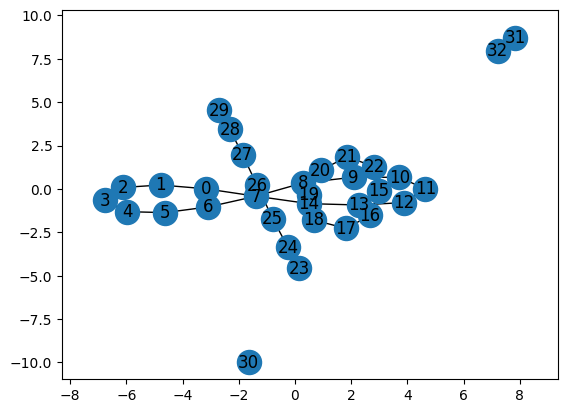

In [2]:
graph = nx.Graph()
graph.add_nodes_from(range(31))

graph.add_edges_from(np.transpose([np.arange(8), np.arange(1, 9)])%8)
graph.add_edges_from(np.transpose([np.arange(7), np.arange(1, 8)])%8 + 7)
graph.add_edges_from([(7, 14)])
graph.add_edges_from(np.transpose([np.arange(8), np.arange(1, 9)])%8 + 15)
graph.add_edges_from(np.transpose([np.arange(6), np.arange(1, 7)]) + 23)
graph.add_edge(31, 32)

pos = nx.spring_layout(graph)
pos = {node: 10*p for node, p in pos.items()}

nx.draw_networkx(graph, pos=pos, hide_ticks=False)

In [3]:
import networkx as nx


def get_chains(graph: nx.Graph, similar_start_end_of_cycle=False):
    """
    Returns the list of all chains of the graph.

    A chain is a maximal path whose internal nodes have degree 2
    (endpoints have degree != 2), or (if a connected component is a
    pure cycle where all nodes have degree 2) the whole cycle as one chain.

    Returns
    -------
    list[list[Hashable]]
        Each chain is returned as an ordered list of nodes.
        For cycle-components, the chain is a cyclic order with the first node
        repeated at the end to make the cycle explicit.
    """
    G = graph

    # Degree in a MultiGraph can be >2 because of parallel edges; this function assumes simple graphs,
    # but we still use G.degree(v) which NetworkX defines for any graph.
    deg = dict(G.degree())

    visited_undirected_edges = set()  # store edges as (min(u,v), max(u,v))

    def mark_edge(u, v):
        a, b = (u, v) if u <= v else (v, u)
        visited_undirected_edges.add((a, b))

    def edge_marked(u, v):
        a, b = (u, v) if u <= v else (v, u)
        return (a, b) in visited_undirected_edges

    chains = []

    # 1) Build chains starting from "junctions" / endpoints: nodes with degree != 2
    for start in G.nodes:
        if deg[start] == 2:
            continue

        for nbr in G.neighbors(start):
            if edge_marked(start, nbr):
                continue

            chain = [start]
            prev = start
            cur = nbr
            mark_edge(prev, cur)

            # Walk forward while we're in degree-2 nodes (internal chain nodes)
            while True:
                chain.append(cur)

                if deg[cur] != 2:
                    # We hit a terminal/junction node: chain ends here.
                    break

                # Choose the next neighbor that isn't the previous node
                nbs = list(G.neighbors(cur))
                # In a simple graph with deg==2, there are exactly 2 neighbors.
                nxt = nbs[0] if nbs[0] != prev else nbs[1]

                if edge_marked(cur, nxt):
                    # We've already consumed this edge; stop to avoid duplicates.
                    break

                prev, cur = cur, nxt
                mark_edge(prev, cur)

            chains.append(chain)

    # 2) Remaining edges (if any) belong to components where all nodes have degree 2 => cycles.
    # We treat each such component as one chain (cycle order).
    for comp in nx.connected_components(G):
        comp_nodes = list(comp)
        if not comp_nodes:
            continue
        if any(deg[v] != 2 for v in comp_nodes):
            continue  # not a pure cycle component

        # If all edges in this component are already visited, skip.
        comp_edges = list(G.subgraph(comp_nodes).edges())
        if all(edge_marked(u, v) for (u, v) in comp_edges):
            continue

        # Build an explicit cyclic order by walking until we return to start.
        start = comp_nodes[0]
        nbrs = list(G.neighbors(start))
        if len(nbrs) != 2:
            # Shouldn't happen in a pure cycle, but be defensive.
            continue

        chain = [start]
        prev = start
        cur = nbrs[0]
        mark_edge(prev, cur)

        while True:
            chain.append(cur)
            if cur == start:
                break

            nbs = list(G.neighbors(cur))
            nxt = nbs[0] if nbs[0] != prev else nbs[1]

            # If we're about to close, allow it; otherwise avoid reusing visited edges.
            if edge_marked(cur, nxt) and nxt != start:
                break

            prev, cur = cur, nxt
            mark_edge(prev, cur)

            if cur == start:
                chain.append(start)
                break

        # Ensure it's a cycle representation: end equals start.
        if chain[-1] != start:
            chain.append(start)

        chains.append(chain)

    if not similar_start_end_of_cycle:
        for i, chain in enumerate(chains):
            if chain[0] == chain[-1]:
                chains[i] = chain[:-1]
    chains = [np.array(chain) for chain in chains]

    return chains

In [4]:
for chain in get_chains(graph):
    print(chain)

[7 6 5 4 3 2 1 0]
[ 7  8  9 10 11 12 13 14]
[23 24 25 26 27 28 29]
[31 32]
[15 16 17 18 19 20 21 22]


In [5]:
def get_derivative_operator(graph, pos):
    """
    """
    nodes_indices = {node: i for i, node in enumerate(graph.nodes())}

    matrix = np.zeros(shape=(graph.number_of_nodes(), graph.number_of_nodes()))
    for chain in get_chains(graph, similar_start_end_of_cycle=False):
        for inode, node in enumerate(chain):
            if graph.degree(node) == 2:
                v0, v1, v2 = chain[np.array([inode - 1, inode, inode + 1])%len(chain)]
                i0, i1, i2 = [nodes_indices[v] for v in (v0, v1, v2)]
                p0, p1, p2 = [pos[v] for v in (v0, v1, v2)]
                d01 = np.linalg.norm(p1 - p0)
                d12 = np.linalg.norm(p2 - p1)
                matrix[i1, i0] += 0.5/d01
                matrix[i1, i1] += 0.5/d01 + 0.5/d12
                matrix[i1, i2] += 0.5/d12
                

    return matrix

In [6]:
def get_derivative_operator(graph, pos):
    """
    """
    nodes_indices = {node: i for i, node in enumerate(graph.nodes())}

    matrix = np.zeros(shape=(graph.number_of_nodes(), graph.number_of_nodes()))
    for chain in get_chains(graph, similar_start_end_of_cycle=True):
        for v0, v1 in itertools.pairwise(chain):
            i0, i1 = [nodes_indices[v] for v in (v0, v1)]
            p0, p1 = [pos[v] for v in (v0, v1)]
            matrix[i0, i1] += 0.5/np.linalg.norm(p1 - p0)
            matrix[i1, i0] -= 0.5/np.linalg.norm(p1 - p0)

    return matrix

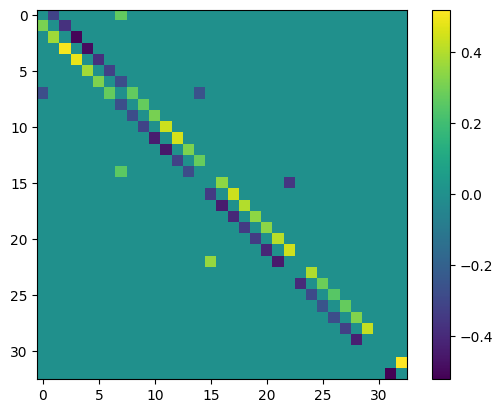

In [7]:
md1 = get_derivative_operator(graph, pos)

plt.colorbar(plt.imshow(md1))

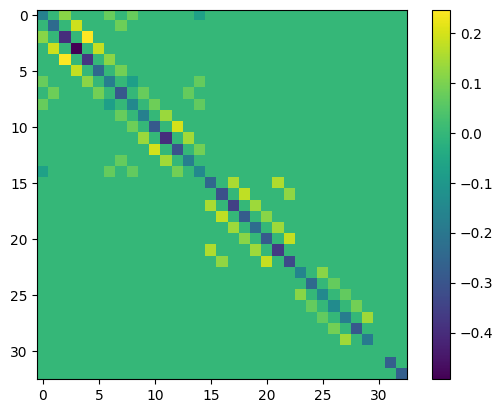

In [8]:
md2 = md1@md1

plt.colorbar(plt.imshow(md2))

In [9]:
md1[[i for i, node in enumerate(graph.nodes) if graph.degree(node) != 2]].shape

(6, 33)

In [10]:
vals, vecs = np.linalg.eig(md2)

In [11]:
import numpy as np

def constrained_real_eig(A, C, assume_symmetric=True, rtol=1e-12, imag_tol=1e-10):
    """
    Solve Ax = λx subject to Cx = 0, returning only (approximately) real eigenpairs.

    Parameters
    ----------
    A : (n,n) array_like
    C : (m,n) array_like
    assume_symmetric : bool
        If True, solves the symmetric reduced problem with eigh (guarantees real output
        when A is symmetric). If False, uses eig and filters real modes.
    rtol : float
        Nullspace tolerance
    imag_tol : float
        Keep eigenpairs whose imaginary part magnitude <= imag_tol

    Returns
    -------
    vals_real : (k,) ndarray
    vecs_real : (n,k) ndarray
        Columns are real constrained eigenvectors
    """
    A = np.asarray(A, dtype=float)
    C = np.asarray(C, dtype=float)

    # Nullspace basis N for Cx=0 using SVD
    U, S, Vt = np.linalg.svd(C, full_matrices=True)
    if S.size == 0:
        N = np.eye(A.shape[0])
    else:
        rank = (S > rtol * S[0]).sum()
        N = Vt[rank:].T

    if N.size == 0:
        raise ValueError("Constraint eliminates entire space")

    A_red = N.T @ A @ N

    if assume_symmetric:
        # Best case: real eigenpairs (if A is truly symmetric)
        vals, vecs_red = np.linalg.eigh(A_red)
        vecs = N @ vecs_red
        vecs = np.real_if_close(vecs, tol=1000)
        vals = np.real_if_close(vals, tol=1000)
        vecs = np.asarray(vecs, dtype=float)
        vals = np.asarray(vals, dtype=float)
    else:
        # General case: may be complex; filter near-real eigenpairs
        vals, vecs_red = np.linalg.eig(A_red)
        keep = (np.abs(np.imag(vals)) <= imag_tol)
        vals = vals[keep]
        vecs_red = vecs_red[:, keep]
        vecs = N @ vecs_red

        # keep only vectors that are also near-real
        keep_vec = (np.max(np.abs(np.imag(vecs)), axis=0) <= imag_tol)
        vals = np.real(vals[keep_vec])
        vecs = np.real(vecs[:, keep_vec])

    # Normalize
    norms = np.linalg.norm(vecs, axis=0, keepdims=True)
    vecs = vecs / np.where(norms == 0, 1.0, norms)

    return vals, vecs

In [12]:
def get_eigen_values_for_graph(graph, pos, with_vals=True):
    """
    """
    md1 = get_derivative_operator(graph, pos)
    md2 = md1@md1
    vals, vecs = constrained_real_eig(md2, md1[[i for i, node in enumerate(graph.nodes) if graph.degree(node) != 2]])
    
    return vals, vecs

In [13]:
vals, vecs = get_eigen_values_for_graph(graph, pos)

vecs.shape

(33, 28)

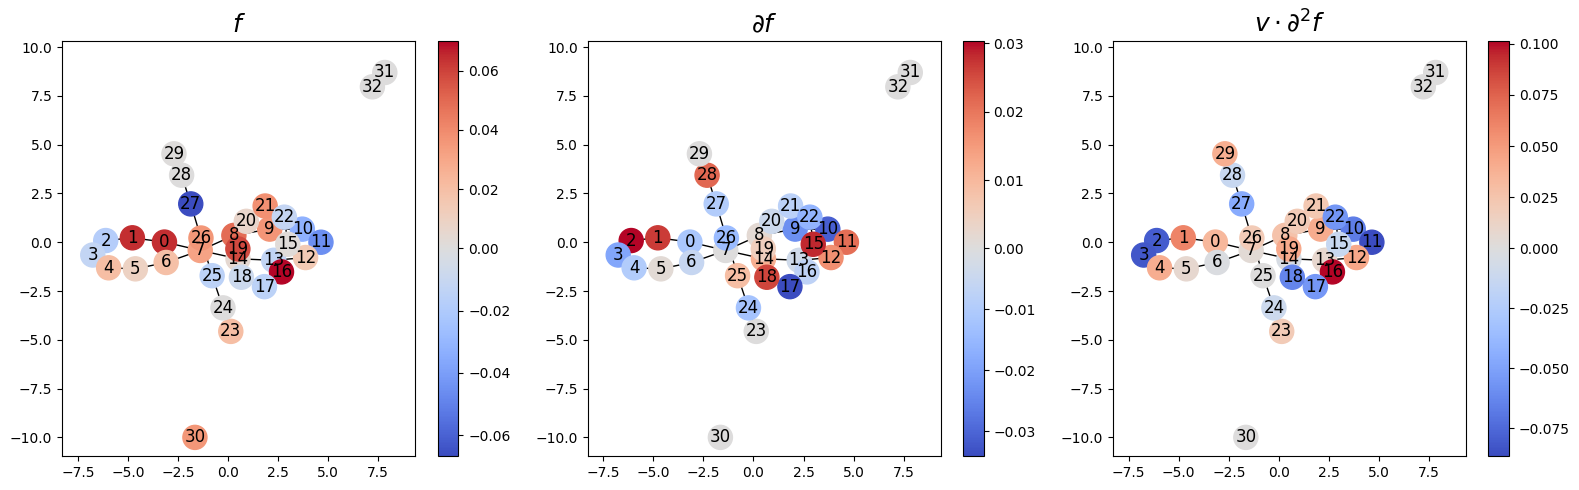

In [14]:
values0 = vecs.mean(axis=1)
values1 = md1 @ values0
values2 = md2 @ values0
values3 = md2 @ values0 / vals.mean()

val_list = [values0, 
            values1, 
            #values2, 
            values3]
titles = ['$f$', 
          r'$\partial f$', 
          #r'$\partial^2 f$', 
          r'$v\cdot\partial^2 f$']

cmap = plt.get_cmap("managua")
cmap = plt.get_cmap('coolwarm')


fig, axs = plt.subplots(1, len(val_list), figsize=(5*len(val_list) + 1, 5))

for i, (val, title) in  enumerate(zip(val_list, titles)):

    axs[i].set_title(title, fontsize=18)
    norm = mcolors.TwoSlopeNorm(vmin=val.min(), vcenter=0, vmax=val.max())
    nx.draw_networkx(graph, pos=pos, node_color=cmap(norm(val)), ax=axs[i], hide_ticks=False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, ax=axs[i])   # or plt.colorbar(sm, ax=ax)

plt.tight_layout()
plt.show()

# For the 2d complex

# Generate a Complex

In [15]:
def diffeo(vertices, a=0.2, b=1.1, c=0.2, d=1.2, e=0.2, f=0.3):
    v = vertices.copy()
    x, y, z = v[:, 0], v[:, 1], v[:, 2]

    v[:, 0] = x + a*np.sin(b*y) + c*np.sin(d*z)
    v[:, 1] = y + e*np.sin(f*x)

    return v

def cylindrical_twist(vertices, k=0.2, mode="x", scale=0.5):
    """
    Nonlinear cylindrical twist diffeomorphism on R^3.

    vertices: (n,3) array
    mode:
      - "z": angle depends on z  (theta = k * tanh(z/scale))
      - "r": angle depends on radius r (theta = k * tanh(r/scale))
    k: twist strength (radians, roughly bounded by +/-k for tanh)
    scale: controls how quickly tanh saturates
    """
    if mode == 'x':
        v = vertices[:, [1, 2, 0]]
        v = cylindrical_twist(v, k=k, mode="z", scale=scale)
        v = v[:, [2, 0, 1]]
        return v
        
    v = vertices.copy()
    x, y, z = v[:, 0], v[:, 1], v[:, 2]

    r = np.sqrt(x*x + y*y)

    if mode == "z":
        theta = k * np.tanh(z / scale)
    elif mode == "r":
        theta = k * np.tanh(r / scale)
    else:
        raise ValueError('mode must be "z" or "r"')

    c, s = np.cos(theta), np.sin(theta)

    v[:, 0] = c * x - s * y
    v[:, 1] = s * x + c * y
    # z unchanged
    return v

In [16]:
n, m = 17, 16

np.random.seed(42)
vertices0, faces0 = shapes.get_halftori_bouquet(leaves=3, n=n, m=m, l0=1.0, extra_points_on_edge=7, extra_points_on_disk=40, glue=True)
vertices0, faces0 = shapes.split_large_edges(vertices0, faces0, max_length=0.7)

n0, n1 = 24, 24
r0, r1 = 0.8, 1.1
vertices1, faces1 = shapes.get_couple_linked_tori(n0=n0, n1=n1, r0=r0, r1=r1)

vertices0 += np.array([vertices0[:, 0].min(), 0, 0])
vertices1 += np.array([vertices1[:, 0].max(), 0, 0])
vertices1, faces1 = shapes.split_large_edges(vertices1, faces1, max_length=0.8)

vertices, faces, _ = shapes.merge_meshes_with_weld(vertices0, faces0, vertices1, faces1)
#vertices, faces = shapes.split_large_edges(vertices, faces, max_length=0.8)

vertices = cylindrical_twist(vertices, k=-0.6, scale=3.2, mode='x')

In [17]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=1.0)
pl.show()

Widget(value='<iframe src="http://localhost:33785/index.html?ui=P_0x7c5902d98b60_0&reconnect=auto" class="pyvi…

## Detect a boundary

In [18]:
def get_boundary_edges(faces):
    """
    """
    face_edges = np.concatenate([faces[:, j] for j in [[0, 1], [0, 2], [1, 2]]])
    face_edges = np.sort(face_edges, axis=1)
    edges = np.unique(face_edges, axis=0)
    edges = edges[(edges[:, None, :] == face_edges).all(axis=-1).sum(axis=-1) != 2]
    return edges

In [19]:
class NonmanifoldBoundaryDetecter:
    def __init__(self, faces, vertices):
        self.faces = np.unique(np.sort(faces, axis=1), axis=0)
        self.vertices = np.array(vertices)

    def get_boundary_edges(self):
        """
        """
        face_edges = np.concatenate([self.faces[:, j] for j in [[0, 1], [0, 2], [1, 2]]])
        face_edges = np.sort(face_edges, axis=1)
        edges = np.unique(face_edges, axis=0)
        edges = edges[(edges[:, None, :] == face_edges).all(axis=-1).sum(axis=-1) != 2]
        return edges

    def get_conic_vertices(self):
        """
        """
        conic_vertices = []
        for vertex in np.unique(self.faces):
            faces_vertex = faces[(faces == vertex).any(axis=1)]
            connections = faces_vertex[:, None, :, None] == faces_vertex[None, :, None, :]
            connections = connections.any(axis=-1).sum(axis=-1) == 2
            n_components, _ = sp.sparse.csgraph.connected_components(connections, directed=False)
            if n_components > 1:
                conic_vertices.append(vertex)
        conic_vertices = np.array(conic_vertices)
        return conic_vertices

    def get_boundary_graph(self, with_boundary_edges: bool=True, with_conic_vertices: bool=True):
        """
        """
        graph = nx.Graph()
        if with_boundary_edges:
            graph.add_edges_from(self.get_boundary_edges())
        if with_conic_vertices:
            graph.add_nodes_from(self.get_conic_vertices())
        return graph

In [20]:
nmb = NonmanifoldBoundaryDetecter(faces, vertices)
boundary_graph = nmb.get_boundary_graph()
boundary_graph_pos = {node: nmb.vertices[node] for node in boundary_graph.nodes}

In [21]:
def best_integer_shape(x, n_max, metric="l2", alphas=2000, refine_steps=25):
    """
    Find integer vector n (same length as x) with 0<=n_i<=n_max
    minimizing distance between x/mean(x) and n/mean(n).

    metric: "l2" or "l1"
    alphas: number of alpha candidates in coarse grid
    refine_steps: local refinement around best alpha
    """
    x = np.asarray(x, dtype=float)
    k = x.size
    if k == 0:
        return np.array([], dtype=int)
    if np.all(x == 0) or np.mean(x) == 0:
        # Degenerate: any n has undefined normalization if mean(n)=0.
        # Return something safe.
        return np.zeros(k, dtype=int)

    # Use nonnegative shape target (common in these problems).
    # If you need signed integers, say so and we can adapt.
    x_pos = np.maximum(x, 0.0)
    x_norm = x_pos / np.mean(x_pos)

    def dist(n):
        m = np.mean(n)
        if m <= 0:
            return np.inf
        n_norm = n / m
        d = x_norm - n_norm
        if metric == "l1":
            return np.sum(np.abs(d))
        return np.sqrt(np.sum(d * d))

    # Coarse alpha range:
    # alpha such that typical rounded values cover [0, n_max]
    # Avoid alpha=0; cap high to allow saturation but not crazy.
    x_mean = np.mean(x_pos)
    x_max = np.max(x_pos)
    alpha_min = 1e-12
    alpha_max = (n_max / (x_mean + 1e-12)) * 4.0  # generous upper bound

    # Coarse grid search
    alpha_grid = np.linspace(alpha_min, alpha_max, alphas)
    best = (np.inf, None, None)

    for a in alpha_grid:
        n = np.rint(a * x_pos).astype(int)
        n = np.clip(n, 0, n_max)
        d = dist(n)
        if d < best[0]:
            best = (d, a, n)

    # Local refinement around best alpha
    best_d, best_a, best_n = best
    a0 = best_a

    # Refine multiplicatively around a0
    for _ in range(refine_steps):
        # try a few nearby candidates
        candidates = a0 * np.array([0.85, 0.92, 0.97, 1.00, 1.03, 1.08, 1.18])
        improved = False
        for a in candidates:
            if a <= 0:
                continue
            n = np.rint(a * x_pos).astype(int)
            n = np.clip(n, 0, n_max)
            d = dist(n)
            if d < best_d:
                best_d, a0, best_n = d, a, n
                improved = True
        if not improved:
            break

    return best_n

In [22]:
x = [5.52581816, 6.23447264, 6.04305935, 2.0, 6.38829137, 4.88483142]

best_integer_shape(x, n_max=6, metric="l2", alphas=2000, refine_steps=25)

array([5, 6, 6, 2, 6, 5])

In [23]:
def get_boundary_values(graph, vertices_pos, n_max=3, metric="l2", alphas=2000, refine_steps=25):
    """
    """
    if isinstance(vertices_pos, dict):
        d = len(next(boundary_graph_pos.values().__iter__()))
        n = np.max(boundary_graph.nodes()).astype(int) + 1
        vertices = np.nan*np.zeros([n, d])
        for node, pos in vertices_pos.items():
            vertices[node] = pos
    else:
        vertices = np.array(vertices_pos)

    chains = get_chains(graph, similar_start_end_of_cycle=True)
    chain_lengths = np.array([np.linalg.norm(vertices[chain[1:]] - vertices[chain[:-1]], axis=-1).sum() for chain in chains])
    chain_lengths_int = best_integer_shape(chain_lengths, n_max=n_max, metric=metric, alphas=alphas, refine_steps=refine_steps)


    node_list = np.array(list(boundary_graph.nodes))
    node_to_vertex = -1*np.ones(vertices.shape[0], dtype=int)
    node_to_vertex[node_list] = np.arange(len(node_list))

    vec_val = np.zeros(boundary_graph.number_of_nodes())
    for i, (chain, length, length_int) in enumerate(zip(chains, chain_lengths, chain_lengths_int)):
        vec_t = np.append(0, np.linalg.norm(vertices[chain][1:] - vertices[chain][:-1], axis=1).cumsum()) / length
        vec_val[node_to_vertex[chain]] = np.cos(2*length_int*np.pi*vec_t)
        
    return vec_val

In [24]:
vec_val = get_boundary_values(boundary_graph, vertices)
vec_val

array([-5.68074275e-01, -9.98175030e-01, -8.61304408e-02, -1.71758370e-01,
       -9.65552391e-01,  3.82378205e-01, -4.64718046e-01, -6.43522195e-01,
        5.17340291e-01,  4.22183494e-01,  1.00000000e+00,  4.01025601e-01,
        7.07106781e-01, -6.78356935e-01, -9.45102595e-01, -7.96637364e-02,
        4.77053532e-01,  4.42000063e-01,  8.20456580e-01,  8.81153447e-01,
        8.61769556e-01,  9.99557926e-01,  9.95607743e-01,  9.96020642e-01,
        8.46471165e-01,  7.73995727e-01,  6.12323400e-17,  7.33443337e-01,
        3.92838132e-01,  2.84215809e-01,  1.37109459e-01, -2.14862610e-01,
       -3.07277300e-01, -7.07106781e-01, -5.33428013e-01, -7.50990956e-01,
       -7.92270903e-01, -1.00000000e+00, -9.52688239e-01, -9.96818526e-01,
       -9.98525415e-01, -9.30525234e-01, -8.45307957e-01, -7.07106781e-01,
       -8.54654280e-01, -5.13062270e-01, -3.60908603e-01, -4.14435918e-01,
       -1.83697020e-16,  8.66266174e-02,  2.53472775e-01,  1.66436432e-01,
        7.07106781e-01,  

In [25]:

md1 = get_derivative_operator(boundary_graph, boundary_graph_pos)
vec_diff = vec_val@md1

norm_val = mcolors.TwoSlopeNorm(vmin=vec_val.min(), vcenter=0, vmax=abs(vec_val).max())
norm_diff = mcolors.TwoSlopeNorm(vmin=vec_val.min(), vcenter=0, vmax=abs(vec_val).max())


node_colors_val = [c for c in plt.get_cmap('coolwarm')(norm_val(vec_val))]
node_colors_diff = [c for c in plt.get_cmap('coolwarm')(norm_diff(vec_diff))]

In [26]:
pl = pv.Plotter(shape=(1, 2), window_size=(1000, 600))

pl.subplot(0, 0)
pl.add_text('f')
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.3)
vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_val, edge_color='black', edge_width=2, node_size=10, add_labels=True)

pl.subplot(0, 1)
pl.add_text('df')
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.3)
vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_diff, edge_color='black', edge_width=2, node_size=10)

pl.link_views()
pl.show()

Widget(value='<iframe src="http://localhost:33785/index.html?ui=P_0x7c58bab8cb00_1&reconnect=auto" class="pyvi…

In [27]:
boundary_vertices = np.array(list(boundary_graph.nodes()))
boundary_values = vec_val

print(f'boundary_vertices.shape = {boundary_vertices.shape}')
print(f'boundary_values.shape = {boundary_values.shape}')


boundary_vertices.shape = (126,)
boundary_values.shape = (126,)


# Remashing

For the given manifold $M$ with a boundary $\partial M$ and the function on a boundary $f: \partial M\to \mathbb{R}$  with defined critical points $\text{Crit}(f) = \text{Crit}^\text{min}(f) \cup \text{Crit}^\text{max}(f)$ we aim to extenf $f$ into $\hat{f}: M\to\mathbb{R}$ ($\hat{f}(x) = f(x)\; \forall x\in\partial M$) preserving $f$ integral lines and critical and regular points on a boundary.

Let's do this in a way, that $\text{Crit}^\text{max}(f) \to \text{Crit}^\text{max}(\hat{f})$ and $\text{Crit}^\text{min}(f) \to \text{Crit}^\text{saddle}(\hat{f})$.

Then the mesh on a boundory $\partial M$ require 2 statements:
1. Each face of the mesh should have maximumu one edge from a boundary (or two edges connected by critical point)
2. Each vertex $s\in \text{Crit}^\text{min}(f)$ should have at least one neighbor $v\in M/\partial M$ such that $s$ is the onlye $v$'s neighbor feom the boundary ($\text{Neighbors}(v)\cap\partial M = \{s\}$).


## Flip Ears

We can remesh given triangulation, removing ears, and get the mesh, satisfying the 1st statement.

In [28]:
def flip_ears(faces):
    """
    """
    ears, ear_opp = igl.ears(faces)

    mask = ear_opp.reshape(-1, 1) != np.arange(3)
    edges_to_flip = faces[ears][mask].reshape(-1, 2)

    faces_contains_fliping_edges = (faces[:, np.array(list(itertools.combinations(range(3), 2)))][..., None, :] == edges_to_flip).all(axis=-1).any(axis=-2)
    assert (faces_contains_fliping_edges.sum(axis=0) == 2).all()
    _face_idx, _edge_idx = np.where(faces_contains_fliping_edges)
    faces_fliping_edges = _face_idx.reshape(-1, 2)
    faces_contains_fliping_edges = faces_contains_fliping_edges.any(axis=1)

    opposite_vertives = faces[faces_fliping_edges].reshape(-1, 6)
    mask = (opposite_vertives[:, None, :] != edges_to_flip[:, :, None]).all(axis=-2)
    opposite_vertives = opposite_vertives[mask].reshape(-1, 2)
    
    new_faces = np.vstack([np.hstack([opposite_vertives, edges_to_flip[:, i].reshape(-1, 1)]) for i in range(2)])
    new_faces = np.vstack([faces[~faces_contains_fliping_edges], new_faces])
    new_faces = np.sort(new_faces, axis=1)
    
    return new_faces

In [29]:
test_faces = np.array([[0, 1, 3], [1, 3, 4], [1, 2, 4], [2, 4, 5], 
                       [3, 4, 6], [4, 6, 7], [4, 5, 7], [5, 8, 7]])


print(f'test_faces.shape = {test_faces.shape}')
test_faces

test_faces.shape = (8, 3)


array([[0, 1, 3],
       [1, 3, 4],
       [1, 2, 4],
       [2, 4, 5],
       [3, 4, 6],
       [4, 6, 7],
       [4, 5, 7],
       [5, 8, 7]])

In [30]:
fliped_faces = flip_ears(test_faces)
print(f'fliped_faces.shape = {fliped_faces.shape}')

fliped_faces

fliped_faces.shape = (8, 3)


array([[1, 2, 4],
       [2, 4, 5],
       [3, 4, 6],
       [4, 6, 7],
       [0, 1, 4],
       [4, 5, 8],
       [0, 3, 4],
       [4, 7, 8]])

## Surrounding Saddles Area 

In [31]:
from src.shapes import split_edge

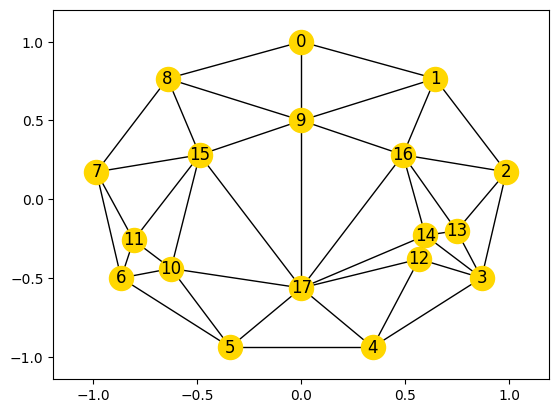

In [32]:
boundary = np.linspace(0, 2*np.pi, 10)[:-1]
boundary = np.transpose([np.sin(boundary), np.cos(boundary)])

saddle0_surrounding = [[0, 0.5]]
saddle1_surrounding = boundary[6] + 0.3*np.array([[0.8, 0.2], [0.2, 0.8]])
saddle2_surrounding = boundary[3] + 0.3*np.array([[-1.0, 0.4], [-0.4, 1.0], [-0.9, 0.9]])

regular_points = [0.6*boundary[edge].mean(axis=0) for edge in [[7, 8], [1, 2], [4, 5]]]


test_vertices = np.vstack([boundary, 
                           saddle0_surrounding, 
                           saddle1_surrounding, 
                           saddle2_surrounding, 
                           regular_points
                           ])

test_faces = sp.spatial.Delaunay(test_vertices).simplices
test_faces = np.sort(test_faces, axis=1)
test_faces = test_faces[(test_faces[:, None, :] != np.array([[3, 12, 13], [12, 13, 14]])).all(axis=1).any(axis=1)]
test_faces = np.vstack([test_faces, [[3, 12, 14], [3, 13, 14]]])


test_graph = nx.Graph()
test_graph.add_nodes_from(range(test_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    test_graph.add_edges_from(test_faces[:, list(i)])

nx.draw_networkx(test_graph, pos=test_vertices, hide_ticks=False, node_color='gold')
plt.grid(False)
plt.show()


In [33]:
def split_edges_arroud_saddles(vertices, faces, saddles, edge_choice_strategy='longest'):
    """
    """
    bnd_edges, bnd_face_indices, bnd_local_edge_indices = igl.boundary_facets(test_faces)
    assert np.isin(saddles, np.unique(bnd_edges)).all()
    bnd_vertices = np.unique(bnd_edges)

    bnd_vertices_nonsaddles = bnd_vertices[~np.isin(bnd_vertices, saddles)]

    adj_full = igl.adjacency_matrix(faces)
    
    saddle_neighbors = np.argwhere(adj_full[saddles])
    saddle_neighbor_is_far_from_boundary = (adj_full[:, bnd_vertices_nonsaddles][saddle_neighbors[:, 1]].toarray() == 0).all(axis=1)

    good_saddles = saddles[saddle_neighbors[:, 0][saddle_neighbor_is_far_from_boundary]]
    

    if set(good_saddles) == set(saddles):
        return vertices, faces
    
    if isinstance(edge_choice_strategy, str):
        if edge_choice_strategy == 'longest':
            f_edge_choice_strategy = lambda edges: np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).argmax()
        if edge_choice_strategy == 'shortest':
            f_edge_choice_strategy = lambda edges: np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).argmin()
    else:
        f_edge_choice_strategy = edge_choice_strategy

    saddles_to_split_arround = saddles[~np.isin(saddles, good_saddles)]

    new_vertices, new_faces = vertices.copy(), faces.copy()
    for saddle in saddles_to_split_arround:
        saddle_faces = faces[(faces == saddle).any(axis=1)]
        mask = saddle_faces != saddle
        saddle_edges = saddle_faces[mask].reshape(-1, 2)

        e0, e1 = saddle_edges[f_edge_choice_strategy(saddle_edges)]
        new_vertices, new_faces = split_edge(new_vertices, new_faces, e0, e1)
    return split_edges_arroud_saddles(new_vertices, new_faces, saddles, edge_choice_strategy=edge_choice_strategy)

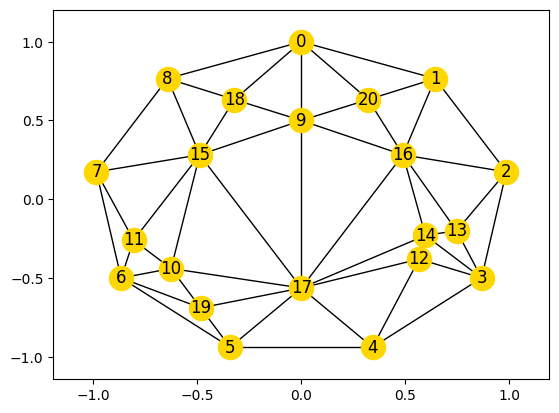

In [34]:
new_vertices, new_faces = split_edges_arroud_saddles(test_vertices, test_faces, np.array([0, 3, 6]))#.toarray()


new_graph = nx.Graph()
new_graph.add_nodes_from(range(new_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    new_graph.add_edges_from(new_faces[:, list(i)])

nx.draw_networkx(new_graph, pos=new_vertices, hide_ticks=False, node_color='gold')
plt.grid(False)
plt.show()


## Boundary Inequality System Solution

When we have a good mesh, satisfying the requrements, we need to define a values arround a boundary, which will not break integral lines and critical points.

So they should satisfy:
1. The value of any point arround local maxima should be lower then this maxima
2. If face $(A, B, C)$ have a boundary edge $(A, B)$, then $f(C) > f(B)$
3. Each saddle should have a neighbor, which does not touch any other vertex of a boundary and have a value lower then this saddle.


We can artificially construct these values in three steps:

1. Define the values arround local maximas:

    Let local maxima be the vertex $A$, and it's neighboring faces are $(A, B_0, B_1)$, ..., $(A, B_i, B_{i + 1})$, $(A, B_{n - 1}, B_n)$, so vertices $A$, $B_0$ and $B_n$ are from the boundary, and we know their values $f(A)$, $f(B_0)$ and $f(B_n)$.
    We can fix some scalar value $\alpha \in (0, 1)$ and define the smallest difference between $f(B_i)$ and $f(A)$:
    $$
        \Delta_A = f(A) - \alpha\cdot\left(f(A) - \max\left\{f(B_0), f(B_n)\right\}\right)
    $$
    Let denote $l_i = ||B_i - B_{i + 1}||$. So for each vertex $B_i$ we can define a map $t: \{B_i\}\to[0, 1]$
    $$
        t(B_i) = \frac{\sum\limits_0^{i - 1} l_i}{\sum\limits_0^{n-1} l_i}
    $$
    and then we can construct a values for each vertex $B_i$:
    $$
        f(B_i) = f(B_0) + t(B_i)\cdot\left(f(B_n) - f(B_0)\right) + \frac{\Delta_A}{2}\cdot\left(1 - \cos(2\pi\cdot t(B_i))\right)
    $$

2. Define the values along integral lines:

    We need to define an ordered list of faces along integral line $(B_0, B_1, C_1)$, $(B_1, B_2, C_2)$, ..., $(B_{i - 1}, B_{i}, C_{i})$, ..., $(B_{n-1}, B_{n}, C_{n})$.
    Here $C_i$ and $C_{i + 1}$ can denote the same vertex, and $(B_0, B_1), (B_1, B_2), ..., (B_{n - 1}, B_n)$ are boundary edges, $B_0 > B_1 > \cdots > B_n$, B_0 is local maxima of the boundary and $B_n$ is local minima of the boundary, so $B_n$ should become a saddle in the extended function.

    We should iteratively go for $i$ from $0$ to $n - 1$. And if $f(C_i)$ is not defined we can set the value 
    $$
        f(C_i) = \beta\cdot f(B_{i - 1}) + (1 - \beta)\cdot f(B_i)
    $$
    where $\beta\in (0, 1)$. We can define $\beta$ by the distances
    $$
        \beta = \frac{||C - B_i||}{||C - B_i|| + ||C - B_{i + 1}||}
    $$

3. Define The values arround local minimas becoming saddles:

    Let local minima be the vertex $A$, and it's neighboring faces are $(A, B_0, B_1)$, ..., $(A, B_i, B_{i + 1})$, ..., $(A, B_{n - 1}, B_n)$, so we already knew or defined on previous steps the values $f(A)$, $f(B_0)$, $f(B_1)$, $f(B_{n - 1})$ and $f(B_n)$.

    Let's define the map $t: \{B_i\}\to[0, 1]$ similar way as we did in step 1.

    Let's constract a function which maps $B_2, ..., B_{n - 2}$ into the values lower than $F(A)$ but with respect of derivatives (or tangents) defined in the points $B_0, B_1, B_{n-1}, B_n$:
    $$
        \tan_0 = \frac{f(B_1) - f(B_0)}{||B_1 - B_0||}, \;\;\;\;
        \tan_1 = \frac{f(B_{n - 1}) - f(B_n)}{||B_{n - 1} - B_n||}
    $$

    $$
    f(B_i) = \frac{1}{\pi}\cdot \cos(\pi\cdot t(B_i)) \cdot\left[(1 - t(B_i))\cdot\tan_0 + t(B_i)\cdot\tan_1\right]
    $$


In [35]:
def detect_mins(faces, bnd_indices, bnd_vals):
    """
    """
    graph = nx.Graph()
    graph.add_edges_from(faces[:, [0, 1]])
    graph.add_edges_from(faces[:, [0, 2]])
    graph.add_edges_from(faces[:, [1, 2]])
    graph = graph.subgraph(bnd_indices)
    f = lambda node: (bnd_vals[list(graph.neighbors(node))] > bnd_vals[node]).all()
    return bnd_indices[np.vectorize(f)(bnd_indices)]

def detect_maxs(faces, bnd_indices, bnd_vals):
    """
    """
    return detect_mins(faces, bnd_indices, -bnd_vals)

In [36]:
import numpy as np
import networkx as nx

def detect_mins(faces, bnd_indices, bnd_vals):
    faces = np.asarray(faces)
    bnd_indices = np.asarray(bnd_indices)
    bnd_vals = np.asarray(bnd_vals)

    if len(bnd_indices) != len(bnd_vals):
        raise ValueError("bnd_indices and bnd_vals must have same length (aligned case).")

    idx = {int(v): i for i, v in enumerate(bnd_indices)}  # global -> local

    G = nx.Graph()
    G.add_edges_from(faces[:, [0, 1]])
    G.add_edges_from(faces[:, [0, 2]])
    G.add_edges_from(faces[:, [1, 2]])
    H = G.subgraph(bnd_indices)

    mins = []
    for v in bnd_indices:
        v = int(v)
        nbs = [u for u in H.neighbors(v) if int(u) in idx]
        if len(nbs) != 2:
            continue
        vloc = idx[v]
        nloc = [idx[int(u)] for u in nbs]
        if (bnd_vals[nloc] > bnd_vals[vloc]).all():
            mins.append(v)

    return np.array(mins, dtype=bnd_indices.dtype)

def detect_maxs(faces, bnd_indices, bnd_vals):
    return detect_mins(faces, bnd_indices, -bnd_vals)

bnd_mins: [ 5 16 27]
bnd_maxs: [ 0 11 21]


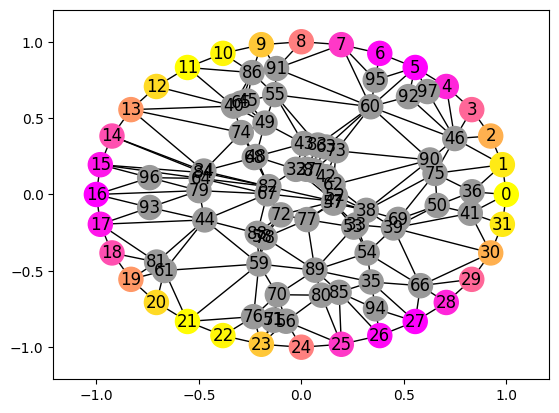

In [37]:
boundary = np.linspace(0, 2*np.pi, 33)[:-1]
boundary = np.transpose([np.cos(boundary), np.sin(boundary)])
bnd_vals = np.cos(np.linspace(0, 6*np.pi, len(boundary) + 1))[:-1]


np.random.seed(47)
test_vertices = np.random.random([60, 2])
test_vertices[:, 0] = (np.arange(len(test_vertices))%5 + 1)/6
test_vertices = test_vertices[:, 0].reshape(-1, 1)*np.transpose([np.sin(2*np.pi*test_vertices[:, 1]), np.cos(2*np.pi*test_vertices[:, 1])])
test_vertices = np.vstack([boundary, test_vertices])

test_faces = sp.spatial.Delaunay(test_vertices).simplices
test_faces = flip_ears(test_faces)

bnd_mins = detect_mins(test_faces, np.arange(len(bnd_vals)), bnd_vals)
bnd_maxs = detect_maxs(test_faces, np.arange(len(bnd_vals)), bnd_vals)
print(f'bnd_mins: {bnd_mins}')
print(f'bnd_maxs: {bnd_maxs}')

test_vertices, test_faces = split_edges_arroud_saddles(test_vertices, test_faces, bnd_mins)

bnd_indices = np.arange(len(bnd_vals))
test_vals = np.nan*np.zeros(test_vertices.shape[0])
test_vals[bnd_indices] = bnd_vals



test_graph = nx.Graph()
test_graph.add_nodes_from(range(test_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    test_graph.add_edges_from(test_faces[:, list(i)])

norm = lambda vals: (vals - vals[~np.isnan(vals)].min())/(vals[~np.isnan(vals)].max() - vals[~np.isnan(vals)].min())
get_colors = lambda vals: [mcolors.to_hex(plt.get_cmap('spring')(val)) if not np.isnan(val) else '#999999' for val in norm(vals)]
node_colors = get_colors(test_vals)

nx.draw_networkx(test_graph, pos=test_vertices, node_color=node_colors, hide_ticks=False)
plt.grid(False)
plt.show()


In [38]:
def get_surrounding_chain(faces, center, boundary_indices):
    """
    """
    surrounding_faces = faces[(faces == center).any(axis=1)]
    surrounding_edges = surrounding_faces[surrounding_faces != center].reshape(-1, 2)
    surrounding_graph = nx.Graph()
    surrounding_graph.add_edges_from(surrounding_edges)
    chain = get_chains(surrounding_graph, similar_start_end_of_cycle=True)[0]
    #print(center, chain)
    if chain[0] == chain[-1]:
        chain = chain[:-1]
        i = np.argwhere(np.isin(chain, boundary_indices)).ravel()
        if len(i) == 0:
            i = 0
        else:
            i = i[0]
        chain = np.roll(chain, -i)
        chain = np.append(chain, chain[0])
    return chain

In [39]:
np.roll(np.arange(6), -1)

array([1, 2, 3, 4, 5, 0])

In [40]:
def split_surrounding_chain(values, chain):
    """
    """
    arr = ~np.isnan(values[chain])

    is0 = np.argwhere(arr[:-1] & ~arr[1:]).ravel()
    is1 = np.argwhere(~arr[:-1] & arr[1:]).ravel() + 2

    cond = is1 - is0 >= 2
    #print(arr)
    #print(is0, is1, cond)
    is0 = is0[cond]
    is1 = is1[cond]
    
    for i0, i1 in zip(is0, is1):
        yield chain[i0:i1]

In [41]:
def all_maximal_paths_dag(G: nx.DiGraph):
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("G must be a DAG")

    sources = [n for n in G.nodes if G.in_degree(n) == 0]

    def dfs(path):
        u = path[-1]
        succ = list(G.successors(u))
        if not succ:                 # sink => path is maximal
            yield path
            return
        for v in succ:
            yield from dfs(path + [v])

    for s in sources:
        yield from dfs([s])

In [42]:
def iterate_integral_face_lines(faces, bnd_indices, bnd_values):
    """
    """
    bnd_faces = faces[np.isin(faces, bnd_indices).sum(axis=1) == 2]
    bnd_edges = bnd_faces[np.isin(bnd_faces, bnd_indices)].reshape(-1, 2)
    bnd_thirds = bnd_faces[~np.isin(bnd_faces, bnd_indices)]
    assert (np.sort(bnd_faces, axis=1) == np.sort(np.hstack([bnd_edges, bnd_thirds.reshape(-1, 1)]), axis=1)).all()

    assert np.isin(bnd_edges, bnd_indices).all()


    bnd_val_dict = {key: value for key, value in zip(bnd_indices, bnd_values)}
    bnd_edge_vals = np.vectorize(bnd_val_dict.get)(bnd_edges)
    
    bnd_edges[bnd_edge_vals[:, 1] > bnd_edge_vals[:, 0]] = bnd_edges[bnd_edge_vals[:, 1] > bnd_edge_vals[:, 0]][:, [1, 0]]

    bnd_graph = nx.DiGraph()
    for (e0, e1), third_vertex in zip(bnd_edges, bnd_thirds):
        bnd_graph.add_edge(e0, e1, third=third_vertex)
    
    for path in all_maximal_paths_dag(bnd_graph):
        e0s = np.array(path)[:-1]
        e1s = np.array(path)[1:]
        v2s = np.array([bnd_graph[e0][e1]['third'] for e0, e1 in zip(e0s, e1s)])
        yield e0s, e1s, v2s

    

In [43]:
def update_values_surround_max(vertices, faces, values, max_index, boundary_indices, alpha=0.5, g=lambda t: 0.5*(1 - np.cos(2*np.pi*t))):
    """
    """
    new_values = values.copy()

    surrounding_chain = get_surrounding_chain(faces, max_index, boundary_indices)

    for subchain in split_surrounding_chain(values, surrounding_chain):
        val0 = values[subchain[0]]
        val1 = values[subchain[-1]]
        val_max = values[max_index]
        delta_val = val_max - max(val0, val1)


        lengths = np.linalg.norm(vertices[subchain[1:]] - vertices[subchain[:-1]], axis=-1)
        t = np.append(0, np.cumsum(lengths))/np.sum(lengths)
        update_val = val0 + (val1 - val0)*t + alpha*delta_val*g(t)

        cond_isnan = np.isnan(new_values)
        new_values[subchain[cond_isnan[subchain]]] = update_val[cond_isnan[subchain]]

    return new_values

In [44]:
def update_values_along_integral_line(values, e0s, e1s, v2s, beta=0.5, vertices=None):
    """
    """
    new_values = values.copy()
    for e0, e1, v2 in zip(e0s, e1s, v2s):
        if np.isnan(new_values[v2]):
            if vertices is not None:
                l0 = np.linalg.norm(vertices[e0] - vertices[v2])
                l1 = np.linalg.norm(vertices[e1] - vertices[v2])
                beta = l0/(l0 + l1)
            new_values[v2] = beta*new_values[e1] + (1 - beta)*new_values[e0]
    return new_values

In [45]:
def update_values_surround_min(vertices, faces, values, min_index, boundary_indices, g=lambda t: np.cos(np.pi*t)/np.pi):
    """
    """
    new_values = values.copy()

    surrounding_chain = get_surrounding_chain(faces, min_index, boundary_indices)
    
    lengths = np.linalg.norm(vertices[surrounding_chain[1:]] - vertices[surrounding_chain[:-1]], axis=-1)
    t = np.append(0, np.cumsum(lengths))/np.sum(lengths)

    tan0 = (values[surrounding_chain[1]] - values[surrounding_chain[0]])/np.linalg.norm(vertices[surrounding_chain[1]] - vertices[surrounding_chain[0]])
    tan1 = (values[surrounding_chain[-2]] - values[surrounding_chain[-1]])/np.linalg.norm(vertices[surrounding_chain[-2]] - vertices[surrounding_chain[-1]])


    g = lambda t: 0.5*(1 - np.cos(2*np.pi*t))
    #update_val = values[min_index] + g(t)*((1 - t)*tan0 + t*tan1)
    update_val = values[min_index] - g(t)

    #print(pd.DataFrame({'id': surrounding_chain, 'new_val': update_val, 'old_val': values[surrounding_chain]}))

    cond_isnan = np.isnan(new_values)
    new_values[surrounding_chain[cond_isnan[surrounding_chain]]] = update_val[cond_isnan[surrounding_chain]]

    return new_values

In [46]:
np.zeros(0)[np.ones(0) > 2]

array([], dtype=float64)

In [47]:
def update_values_surround_regular(vertices, faces, values, regular_index, boundary_indices, g=lambda t: 0.5 + 0.5*np.sin(np.pi*(t - 0.5))):
    """
    """
    new_values = values.copy()

    surrounding_chain = get_surrounding_chain(faces, regular_index, boundary_indices)

    surrounding_chain_is_nan = np.isnan(values[surrounding_chain])
    if not surrounding_chain_is_nan.any():
        return new_values
    
    #print(regular_index, surrounding_chain)
    
    for subchain in split_surrounding_chain(values, surrounding_chain):
        v0 = values[subchain[0]]
        v1 = values[subchain[-1]]
        ls = np.linalg.norm(vertices[subchain[1:]] - vertices[subchain[:-1]], axis=1)
        ts = np.append(0, np.cumsum(ls))/ls.sum()
        subchain_vals = v0 + (v1 - v0)*g(ts)
        new_values[subchain] = subchain_vals

    return new_values


In [48]:
def detect_conics(faces, boundary_indices):
    """
    """
    adj = igl.adjacency_matrix(faces)[boundary_indices][:, boundary_indices].toarray()
    isolated_points = boundary_indices[(adj.sum(axis=1) == 0)]
    return isolated_points


def update_values_surround_conic(vertices, faces, values, conic_index, boundary_indices, delta=-0.1):
    """
    """

    surrounding_chain = get_surrounding_chain(faces, conic_index, boundary_indices)

    if not np.isnan(values[surrounding_chain]).all():
        surrounding_values = values[surrounding_chain][~np.isnan(values[surrounding_chain])]
        if (surrounding_values > values[conic_index]).all() or (surrounding_values < values[conic_index]).all():
            new_values = update_values_surround_regular(vertices, faces, values, conic_index, boundary_indices, g=lambda t: t)
        else:
            pass
            raise ValueError('Unexpected Case, when isolated critical point should became a saddle')
        return new_values

    new_values = values.copy()

    #ls = np.linalg.norm(vertices[surrounding_chain[1:]] - vertices[surrounding_chain[:-1]], axis=1)
    #ts = np.append(0, np.cumsum(ls)/np.sum(ls))
    #
    #if surrounding_chain[0] == surrounding_chain[-1]:
    #    surrounding_chain = surrounding_chain[:-1]
    #    ts = ts[:-1]
    
    #chain_values = values[conic_index] + delta + delta*np.sin(2*np.pi*ts)

    rs = np.linalg.norm(vertices[surrounding_chain] - vertices[conic_index], axis=1)
    rs = np.random.random(len(rs))
    #print('id', conic_index, 'val:', values[conic_index])
    chain_values = values[conic_index] + rs*delta
    
    #new_values[surrounding_chain] = chain_values
    #print(chain_values)
    return new_values
    




In [49]:
detect_conics(faces=test_faces, boundary_indices=np.arange(len(bnd_vals)))

array([], dtype=int64)

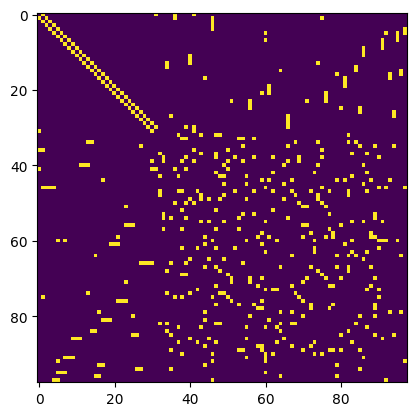

In [50]:
plt.imshow(igl.adjacency_matrix(test_faces).toarray())

In [51]:
def get_second_boundary_values(vertices, faces, boundary_indices, boundary_values, 
                               alpha=0.5, g_max=lambda t: 0.5*(1 - np.cos(2*np.pi*t)), 
                               beta=None, g_min=lambda t: np.cos(np.pi*t)/np.pi, 
                               g_reg=lambda t: t, delta=-0.1):
    """
    """
    boundary_mins = detect_mins(faces, boundary_indices, boundary_values)
    boundary_maxs = detect_maxs(faces, boundary_indices, boundary_values)
    boundary_cons = detect_conics(faces, boundary_indices)
    boundary_regs = np.setdiff1d(boundary_indices, np.concatenate([boundary_mins, boundary_maxs, boundary_cons]))

    values = np.nan*np.ones(len(vertices))
    values[boundary_indices] = boundary_values

    #print('max')
    for max_index in boundary_maxs:
        values = update_values_surround_max(vertices=vertices, faces=faces, values=values, max_index=max_index, boundary_indices=boundary_indices, alpha=alpha, g=g_max)

    #print('regular-0')
    for e0s, e1s, v2s  in iterate_integral_face_lines(faces, bnd_indices=boundary_indices, bnd_values=boundary_values):
        values = update_values_along_integral_line(values, e0s, e1s, v2s, beta=beta, vertices=vertices if beta is None else None)
    
    #print('min')
    for min_index in boundary_mins:
        values = update_values_surround_min(vertices, faces, values, min_index=min_index, boundary_indices=boundary_indices, g=g_min)
    
    #print('regular-1')
    for regular_index in boundary_regs:
        values = update_values_surround_regular(vertices, faces, values, regular_index=regular_index, boundary_indices=boundary_indices, g=g_reg)

    #print('conic')
    for conic_index in boundary_cons:
        values = update_values_surround_conic(vertices, faces, values, conic_index, boundary_indices, delta=0.1)

    second_boundary_indices = np.argwhere(~(np.isnan(values) | np.isin(np.arange(len(values)), boundary_indices))).ravel()
    second_boundary_values = values[second_boundary_indices]

    return second_boundary_indices, second_boundary_values

    

In [52]:
second_bnd_indices, second_bnd_values = get_second_boundary_values(vertices=test_vertices, faces=test_faces, 
                                                                   boundary_indices=np.arange(len(bnd_vals)), boundary_values=bnd_vals)



In [53]:
from src.triangletools import compact_mesh

In [54]:
def solve_second_boundary_hermonics(vertices, faces, boundary_indices, boundary_values, 
                                    alpha=0.5, g_max=lambda t: 0.5*(1 - np.cos(2*np.pi*t)), 
                                    beta=None, g_min=lambda t: np.cos(np.pi*t)/np.pi, k=2):
    """
    """
    second_boundary_indices, second_boundary_values = get_second_boundary_values(vertices, faces, boundary_indices, boundary_values, 
                                                                                 alpha=alpha, g_max=g_max, beta=beta, g_min=g_min)
    
    faces_small = faces[~np.isin(faces, boundary_indices).any(axis=1)]
    vertices_small, faces_small, big2small, small2big = compact_mesh(vertices, faces_small)

    second_boundary_indices_small = big2small[second_boundary_indices]
    bc = second_boundary_values[second_boundary_indices_small != -1].reshape(-1, 1)
    b = second_boundary_indices_small[second_boundary_indices_small != -1]

    u_small = igl.harmonic(vertices_small, faces_small, b, bc, k).ravel()

    u = np.nan*np.ones(len(vertices))
    u[small2big[np.arange(len(u_small))]] = u_small
    u[second_boundary_indices] = second_boundary_values
    u[boundary_indices] = boundary_values

    return u

vals_harmonic.shape = (98,)


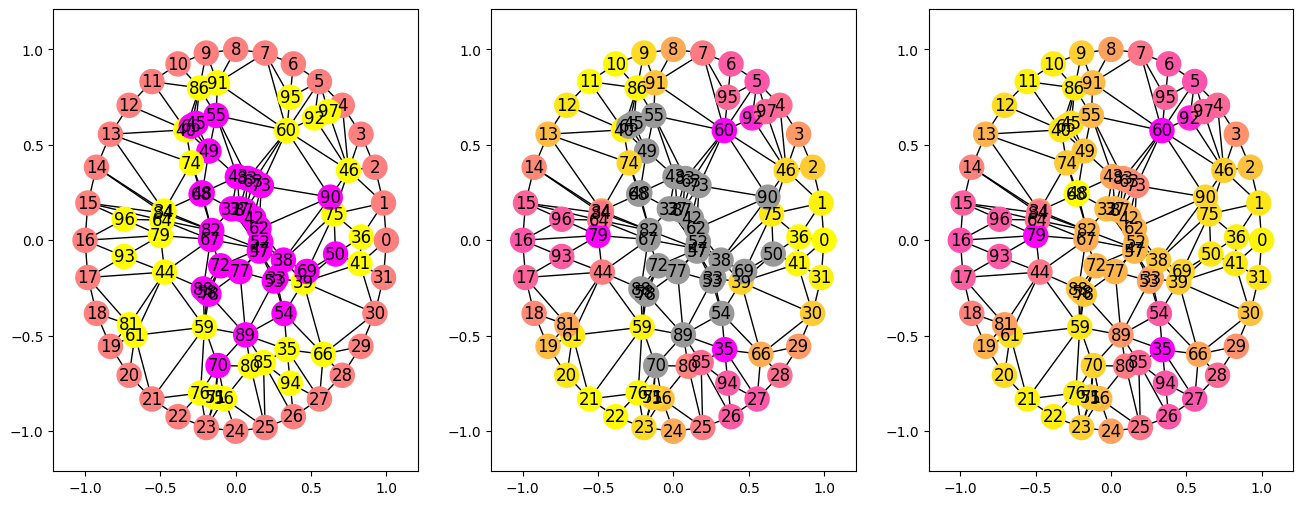

In [55]:
vals = np.nan*np.ones(len(test_vertices))
vals[np.arange(len(bnd_vals))] = bnd_vals
vals[second_bnd_indices] = second_bnd_values

vals_harmonic = solve_second_boundary_hermonics(test_vertices, test_faces, np.arange(len(bnd_vals)), bnd_vals)
print(f'vals_harmonic.shape = {vals_harmonic.shape}')

stats = np.zeros(len(test_vertices))
stats[np.arange(len(bnd_vals))] += 1
stats[second_bnd_indices] += 2

node_colors_stats = get_colors(stats)
node_colors_vals = get_colors(vals)
node_colors_harmonic = get_colors(vals_harmonic)

fig, axs = plt.subplots(1, 3, figsize=(16, 6))

nx.draw_networkx(test_graph, pos=test_vertices, node_color=node_colors_stats, hide_ticks=False, ax=axs[0])
nx.draw_networkx(test_graph, pos=test_vertices, node_color=node_colors_vals, hide_ticks=False, ax=axs[1])
nx.draw_networkx(test_graph, pos=test_vertices, node_color=node_colors_harmonic, hide_ticks=False, ax=axs[2])
plt.show()


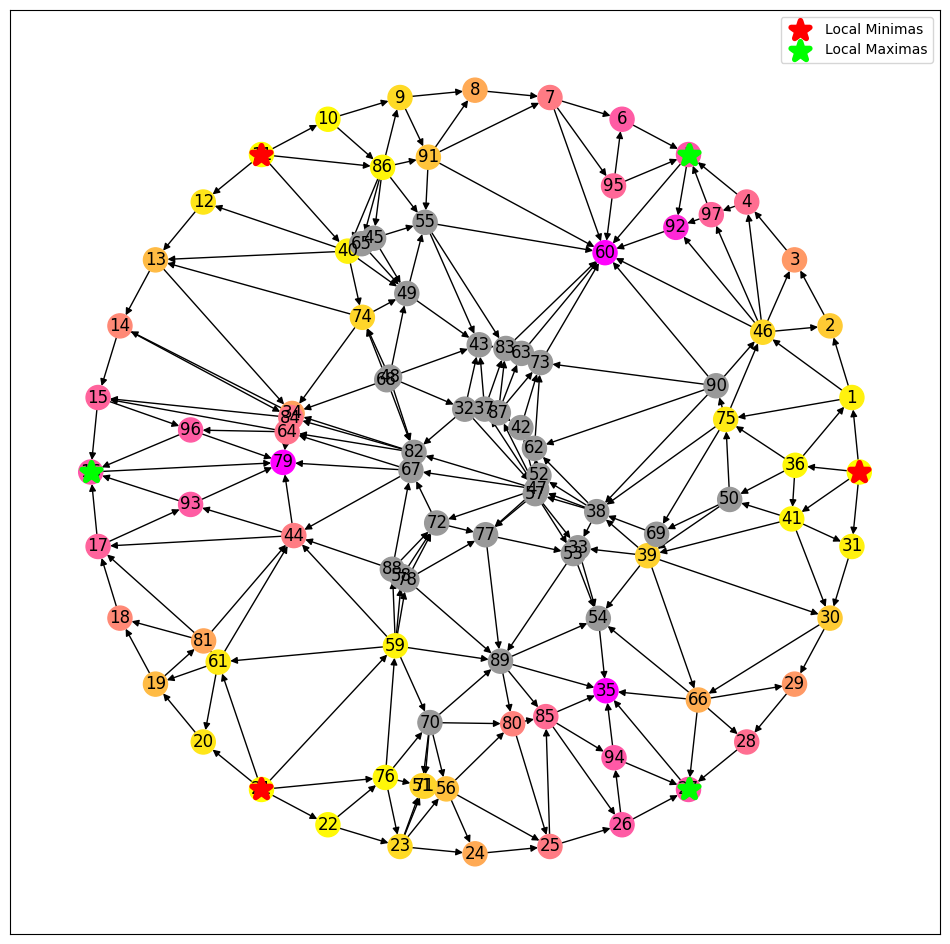

In [56]:
plt.figure(figsize=(12, 12))

test_graph_dirs = nx.DiGraph()
test_graph_dirs.add_nodes_from(test_graph.nodes)
for e0, e1 in test_graph.edges():
    if vals_harmonic[e0] > vals_harmonic[e1]:
        test_graph_dirs.add_edge(e0, e1)
    if vals_harmonic[e0] < vals_harmonic[e1]:
        test_graph_dirs.add_edge(e1, e0)
    


nx.draw_networkx(test_graph_dirs, pos=test_vertices, node_color=node_colors_vals)
plt.scatter(test_vertices[bnd_maxs][:, 0], test_vertices[bnd_maxs][:, 1], color='red', marker='*', linewidth=4, s=200, zorder=4, label='Local Minimas')
plt.scatter(test_vertices[bnd_mins][:, 0], test_vertices[bnd_mins][:, 1], color='lime', marker='*', linewidth=4, s=200, zorder=4, label='Local Maximas')
plt.legend()
plt.show()

In [57]:
test_vertices_3d = np.zeros([test_vertices.shape[0], 3])
test_vertices_3d[:, :2] = test_vertices

from src.ms import MorseSmale
ms = MorseSmale(test_faces, vals_harmonic, test_vertices_3d, gradient_respects_distance=False)
ms.define_critical_points()

pl = pv.Plotter(window_size=(600, 600))
vis.add_complex_to_plotter(pl, ms, path_color='orchid')

g_boundary = nx.Graph()
g_boundary.add_nodes_from(np.arange(32))
vis.add_graph_to_plotter(pl, g_boundary, pos={node: test_vertices_3d[node] for node in g_boundary.nodes()}, add_labels=True, node_size=0)

pl.show()

Widget(value='<iframe src="http://localhost:33785/index.html?ui=P_0x7c589fa6f860_2&reconnect=auto" class="pyvi…

In [58]:
from scipy.sparse import linalg as spla


def dirichlet_laplacian_eigenfunctions(vertices, faces, k=10, which="LM"):
    """
    Compute k Dirichlet eigenfunctions of the Laplace–Beltrami operator:
        (-L_ff) u = lambda * M_ff u, with u(boundary)=0.

    Returns:
        evals: (k,) eigenvalues
        evecs_full: (n, k) eigenvectors padded with zeros on boundary
    """
    L = igl.cotmatrix(vertices, faces)
    M = igl.massmatrix(vertices, faces, igl.MASSMATRIX_TYPE_VORONOI)

    boundary_vertices = np.ravel(igl.is_border_vertex(faces))
    interrior_vertices = ~boundary_vertices

    Lff = L[interrior_vertices][:, interrior_vertices]
    Mff = M[interrior_vertices][:, interrior_vertices]

    A = (-Lff).tocsc()
    B = Mff.tocsc()

    k_eff = min(k, A.shape[0] - 2) if A.shape[0] > 2 else 1

    # Shift-invert near 0 to get smallest eigenvalues robustly
    evals, evecs_f = spla.eigsh(A, k=k_eff, M=B, sigma=0.0, which=which)

    # Pad back to full vectors with zeros on boundary
    evecs = np.zeros((vertices.shape[0], evecs_f.shape[1]), dtype=float)
    evecs[interrior_vertices, :] = evecs_f

    # Sort
    order = np.argsort(evals)
    return evals[order], evecs[:, order]


In [59]:
def second_boundary_dirichlet_laplacian_eigenfunctions(vertices, faces, boundary_indices=None, k=10, which="SM"):
    """
    """
    if boundary_indices is None:
        boundary_indices = np.argwhere(igl.is_border_vertex(faces)).ravel()

    faces_small = faces[~np.isin(faces, boundary_indices).any(axis=1)]
    vertices_small, faces_small, big2small, small2big = compact_mesh(vertices, faces_small)

    evals, evecs_small = dirichlet_laplacian_eigenfunctions(vertices_small, faces_small, k=k, which=which)
    evecs = np.zeros([vertices.shape[0], k], dtype=float)
    evecs[small2big[np.unique(faces_small)]] = evecs_small
    
    return evals, evecs

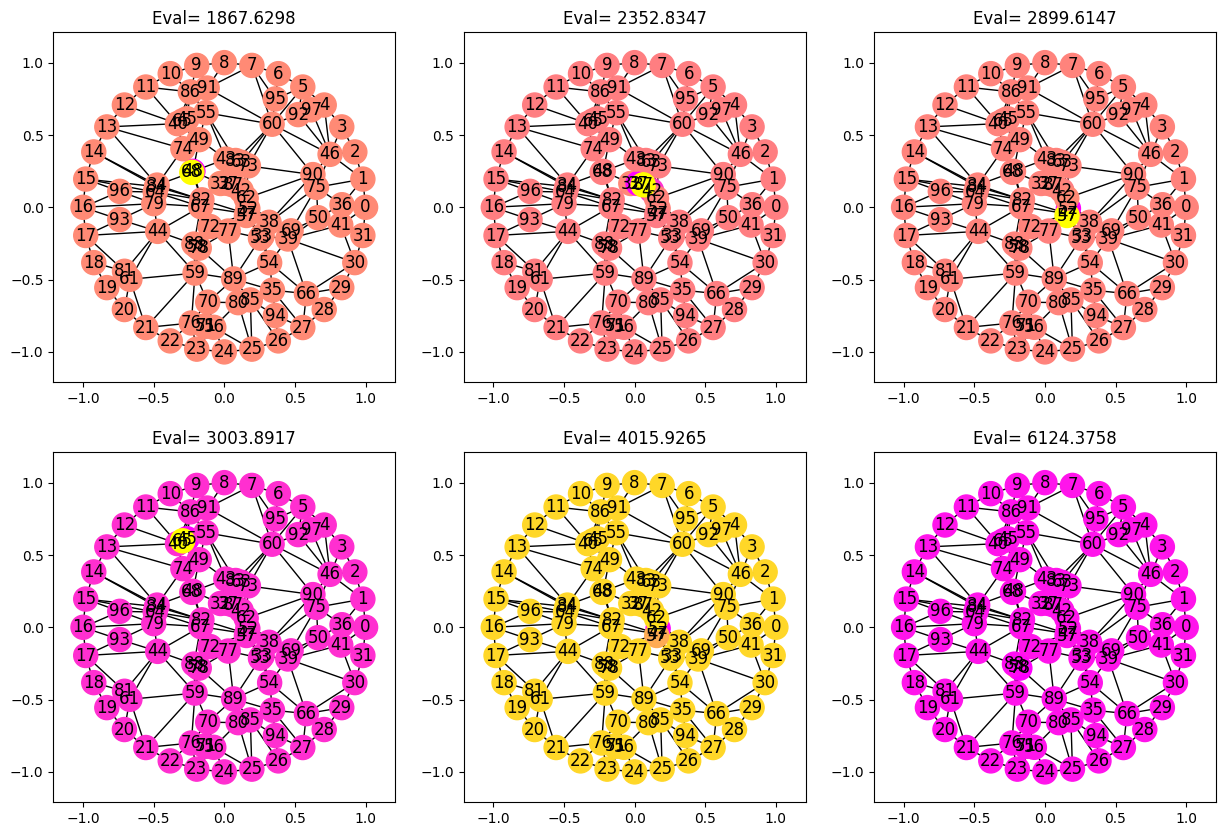

In [60]:
evals, evecs = second_boundary_dirichlet_laplacian_eigenfunctions(test_vertices, test_faces, k=6)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i, eval in zip(range(6), evals):
    i_row = i//3
    i_col = i%3
    axs[i_row, i_col].set_title(f'Eval={eval: .4f}')
    node_colors_eigen = get_colors(evecs[:, i])
    nx.draw_networkx(test_graph, pos=test_vertices, node_color=node_colors_eigen, hide_ticks=False, ax=axs[i_row, i_col])

plt.show()


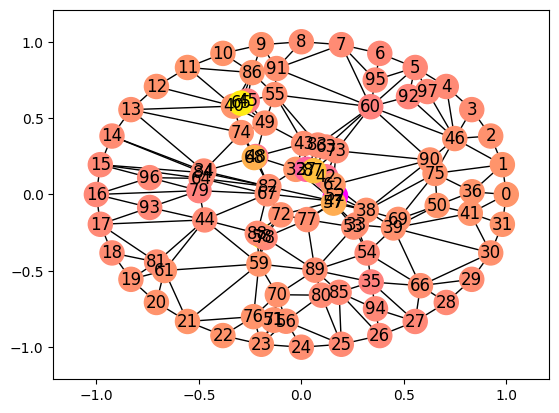

In [61]:
coeffs = np.ones(evecs.shape[1])
vals_harm_plus_eigen = (evecs*coeffs).sum(axis=1) + vals_harmonic

node_colors_harm_plus_eigen = get_colors(vals_harm_plus_eigen)

nx.draw_networkx(test_graph, pos=test_vertices, node_color=node_colors_harm_plus_eigen, hide_ticks=False)
plt.show()

# Quadrangulation of Manifold Components

In [62]:
import numpy as np
from collections import defaultdict, deque

def get_manifold_components(faces):
    """
    Returns the labels of manifold components for each face.

    Each component is manifold, separated by non-manifold edges.
    """

    n_faces = faces.shape[0]
    component_labels = -np.ones(n_faces, dtype=int)

    # --- Step 1: Build edge → faces map ---
    edge_to_faces = defaultdict(list)

    for fi, face in enumerate(faces):
        k = len(face)
        for i in range(k):
            v1 = face[i]
            v2 = face[(i + 1) % k]

            edge = tuple(sorted((v1, v2)))
            edge_to_faces[edge].append(fi)

    # --- Step 2: Build adjacency using manifold edges only ---
    adjacency = defaultdict(list)

    for edge, incident_faces in edge_to_faces.items():
        if len(incident_faces) == 2:  # manifold edge
            f1, f2 = incident_faces
            adjacency[f1].append(f2)
            adjacency[f2].append(f1)

    # --- Step 3: Connected components on faces ---
    current_label = 0

    for start_face in range(n_faces):
        if component_labels[start_face] != -1:
            continue

        # BFS / DFS
        queue = deque([start_face])
        component_labels[start_face] = current_label

        while queue:
            f = queue.popleft()

            for neighbor in adjacency[f]:
                if component_labels[neighbor] == -1:
                    component_labels[neighbor] = current_label
                    queue.append(neighbor)

        current_label += 1

    return component_labels

In [63]:
component_labels = get_manifold_components(faces)

In [64]:
pl = pv.Plotter(window_size=(600, 600))

mesh.cell_data['component'] = component_labels
pl.add_mesh(mesh, scalars='component', cmap='rainbow', smooth_shading=False, show_edges=True, opacity=1.0, categories=True)

pl.show()

Widget(value='<iframe src="http://localhost:33785/index.html?ui=P_0x7c589c0ec650_3&reconnect=auto" class="pyvi…

In [65]:
from src.ms import MorseSmale
from src import triangletools, vis

In [66]:
boundary_vertices

array([ 418,  420,  437,  419,  421,  438,  422,  423,  424,  425,  426,
        427,  488,  428,  429,  430,  439,  440,  441,  442,  473,  474,
        475,  513,  514,  515,  548,  537,  538,  539,  592,  593,  594,
        607,  614,  615,  616,  670,  658,  659,  671,  708,  709,  717,
        710,  730,  731,  732,  777,  785,  786,  787,  836,  809,  810,
        811,  849,  850,  851,  902,  882,  883,  884,  885,  886,  887,
        894,  895,  906,  896,  897,  898,  899,  900,  901,  903,  904,
        905, 1475, 1480, 1481, 1512, 1513, 1542, 1543, 1596, 1597, 1642,
       1643, 1685, 1686, 1738, 1739, 1790, 1791, 1854, 1855, 1900, 1901,
       1922, 1923, 1940, 1947, 1948, 1981, 1982, 2015, 2016, 2063, 2064,
       2101, 2102, 2146, 2147, 2181, 2182, 2219, 2220, 2255, 2256, 2281,
       2282, 2301, 2302, 2309, 1320])

In [67]:
components_mss = []

for i in np.unique(component_labels):
    print(i)
    V2, F2, old2new, new2old = triangletools.compact_mesh(vertices, faces[component_labels == i])
    boundary_is_in_component = np.isin(boundary_vertices, np.unique(faces[component_labels == i]))
    comp_boundary_indices_old = boundary_vertices[boundary_is_in_component]
    comp_boundary_indices_new = old2new[comp_boundary_indices_old]
    comp_boundary_values = boundary_values[boundary_is_in_component]

    

    #pl = pv.Plotter(window_size=(600, 600))
    #pl.add_mesh(vis.get_pv_mesh(V2, F2), color='white', opacity=0.8, smooth_shading=False, show_edges=True)
    

    #g = nx.Graph()
    #g.add_nodes_from(np.arange(len(V2)))
    #g.add_edges_from(F2[:, [0, 1]])
    #g.add_edges_from(F2[:, [0, 2]])
    #g.add_edges_from(F2[:, [1, 2]])
    #g = g.subgraph([1181, 1168, 1137, 1180, 1169, 1141, 1182, 1170, 1140, 1179, 1168])
    #g = g.subgraph([755, 757, 759, 768, 771, 783])
    #vis.add_graph_to_plotter(pl, g, pos={node: V2[node] for node in g.nodes()}, add_labels=True)

    #pl.add_points(V2[comp_boundary_indices_new], color='blue')

    #pl.show()

    harmonic_part = solve_second_boundary_hermonics(V2, F2, comp_boundary_indices_new, comp_boundary_values)
    evals, evecs = second_boundary_dirichlet_laplacian_eigenfunctions(V2, F2, k=1)

    u = harmonic_part + evecs.sum(axis=1)


    components_mss.append(MorseSmale(faces=F2, values=u, vertices=V2))
    components_mss[-1].define_critical_points()


0
1
2
3
4
5


In [68]:
pd.DataFrame({'id': comp_boundary_indices_new, 'val': comp_boundary_values})

,id,val
0,0,-1.000000
1,1,-0.712105
2,2,-0.712105
3,17,-0.016999
4,18,-0.016999
5,27,0.689255
6,28,0.689255
7,47,0.999834
8,48,0.999834
9,65,0.696813


In [69]:
comp_boundary_indices_new, comp_boundary_values

(array([  0,   1,   2,  17,  18,  27,  28,  47,  48,  65,  66,  85,  86,
        115, 116, 139, 140, 169, 170, 195, 196, 201, 202, 215, 222, 223,
        240, 241, 258, 259, 284, 285, 310, 311, 335, 336, 360, 361, 386,
        387, 412, 413, 430, 431, 448, 449, 456]),
 array([-1.        , -0.7121055 , -0.7121055 , -0.01699921, -0.01699921,
         0.6892552 ,  0.6892552 ,  0.9998344 ,  0.9998344 ,  0.69681339,
         0.69681339, -0.07181232, -0.07181232, -0.79797964, -0.79797964,
        -0.9817445 , -0.9817445 , -0.54503747, -0.54503747,  0.17813343,
         0.17813343,  0.77646562,  0.77646562,  1.        ,  0.8684677 ,
         0.8684677 ,  0.50759707,  0.50759707,  0.0104909 ,  0.0104909 ,
        -0.49229512, -0.49229512, -0.86427935, -0.86427935, -0.99998794,
        -0.99998794, -0.85883812, -0.85883812, -0.48124479, -0.48124479,
         0.02425196,  0.02425196,  0.5180665 ,  0.5180665 ,  0.87204263,
         0.87204263,  1.        ]))

In [70]:
ms = components_mss[2]
g = ms.get_decreasing_graph()


pl = pv.Plotter()

vis.add_complex_to_plotter(pl, ms)
vis.add_graph_to_plotter(pl, g, ms.vertices, arrow_scale=0.2, arrow_color='red')



pl.show()

Widget(value='<iframe src="http://localhost:33785/index.html?ui=P_0x7c588ff0c2f0_4&reconnect=auto" class="pyvi…

In [71]:
rows = int(len(components_mss)**0.5)
cols = np.ceil(len(components_mss)/rows).astype(int)

pl = pv.Plotter(shape=(rows, cols), window_size=(1200, 1000))

for i in range(len(components_mss)):
    i_col = i//rows
    i_row = i% rows
    pl.subplot(i_row, i_col)
    for j, ms in enumerate(components_mss):
        if i == j:
            vis.add_complex_to_plotter(pl, ms, eps=0)
        else:
            vis.add_complex_to_plotter(pl, ms, opacity=0.4, with_values=False, with_critical_points=False, with_paths=False)

pl.link_views()
pl.show()


Widget(value='<iframe src="http://localhost:33785/index.html?ui=P_0x7c588ff0df40_5&reconnect=auto" class="pyvi…